In [1]:
import numpy as np
import pandas as pd
#import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_colwidth', None)
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

In [2]:
df_ev = pd.read_csv("data/cleaned_chargingdata.csv")

In [5]:
# Remove timezone offset information from the string column before conversion
df_ev['connectionTime'] = df_ev['connectionTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev['disconnectTime'] = df_ev['disconnectTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)
df_ev['doneChargingTime'] = df_ev['doneChargingTime'].str.replace(r'(-08:00)|(-07:00)', '', regex=True)

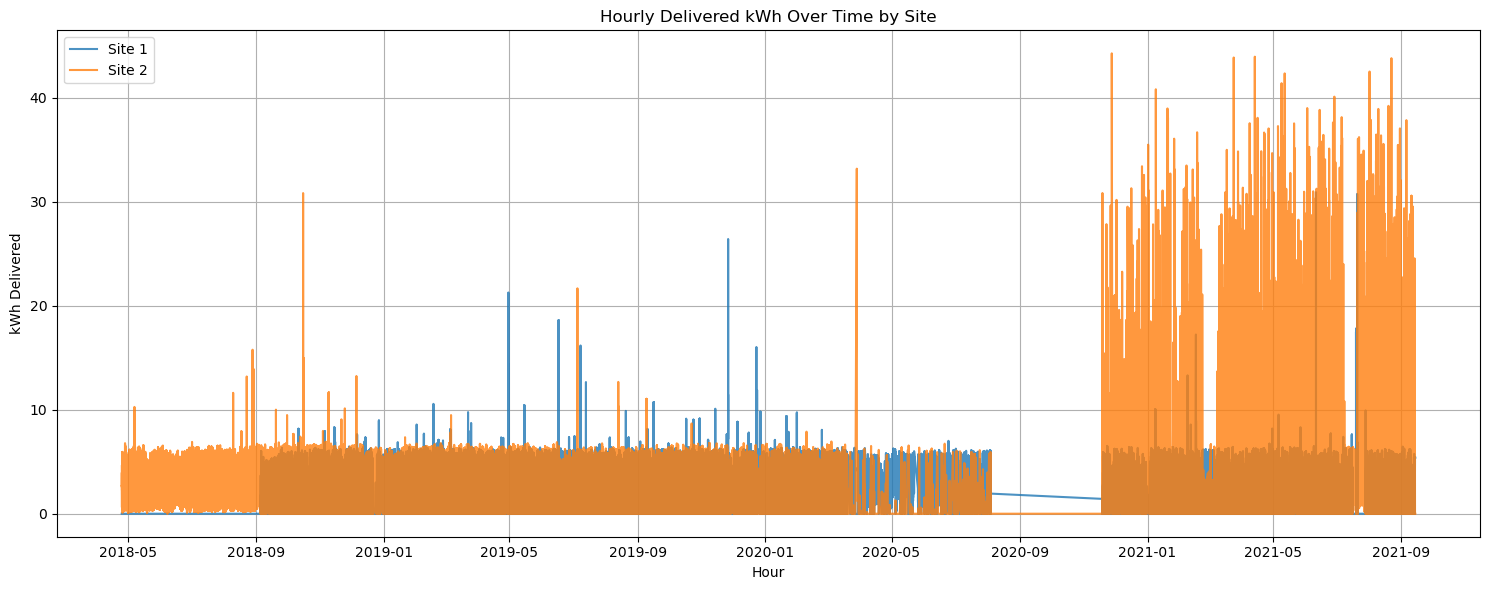

In [6]:
# Ensure 'connectionTime' and 'doneChargingTime' are in datetime format
df_ev['connectionTime'] = pd.to_datetime(df_ev['connectionTime'])
df_ev['doneChargingTime'] = pd.to_datetime(df_ev['doneChargingTime'])

# Create an empty DataFrame to store hourly kWh delivered
hourly_kwh = pd.DataFrame()

# Process each row/session
for _, row in df_ev.iterrows():
    # Extract session details
    start_time = row['connectionTime']
    end_time = row['doneChargingTime']
    total_kwh = row['kWhDelivered']
    site_id = row['siteID']
    
    # Generate hourly timestamps between start and end
    hourly_range = pd.date_range(start=start_time, end=end_time, freq='H')
    
    # Compute kWh per hour
    if len(hourly_range) > 1:  # More than one hour
        kwh_per_hour = total_kwh / len(hourly_range)
    else:  # Single hour
        kwh_per_hour = total_kwh
    
    # Create a DataFrame for this session's hourly contribution
    session_data = pd.DataFrame({
        'hour': hourly_range,
        'siteID': site_id,
        'kWhDelivered': kwh_per_hour
    })
    
    # Append to the main hourly kWh DataFrame
    hourly_kwh = pd.concat([hourly_kwh, session_data], ignore_index=True)

# Group by hour and siteID and sum up the kWh delivered
hourly_kwh_summary = hourly_kwh.groupby(['hour', 'siteID'])['kWhDelivered'].sum().unstack(fill_value=0).reset_index()

# Rename columns for clarity
hourly_kwh_summary.columns.name = None  # Remove the multi-index name
hourly_kwh_summary.columns = ['hour', 'site_1_kWh', 'site_2_kWh']

# Plot the hourly delivered kWh for each site
plt.figure(figsize=(15, 6))
plt.plot(hourly_kwh_summary['hour'], hourly_kwh_summary['site_1_kWh'], label='Site 1', alpha=0.8)
plt.plot(hourly_kwh_summary['hour'], hourly_kwh_summary['site_2_kWh'], label='Site 2', alpha=0.8)
plt.title('Hourly Delivered kWh Over Time by Site')
plt.xlabel('Hour')
plt.ylabel('kWh Delivered')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

In [7]:
hourly_kwh_summary

,hour,site_1_kWh,site_2_kWh
0,2018-04-25 04:08:04,0.0000,2.644000
1,2018-04-25 05:08:04,0.0000,2.644000
2,2018-04-25 06:08:04,0.0000,2.644000
3,2018-04-25 06:45:10,0.0000,3.337667
4,2018-04-25 06:45:50,0.0000,2.628500
...,...,...,...
263794,2021-09-14 03:43:39,5.3937,0.000000
263795,2021-09-14 04:43:39,5.3937,0.000000
263796,2021-09-14 05:43:39,5.3937,0.000000
263797,2021-09-14 06:43:39,5.3937,0.000000


In [8]:
hourly_kwh

,hour,siteID,kWhDelivered
0,2020-01-02 05:08:54,1,5.00320
1,2020-01-02 06:08:54,1,5.00320
2,2020-01-02 07:08:54,1,5.00320
3,2020-01-02 08:08:54,1,5.00320
4,2020-01-02 09:08:54,1,5.00320
...,...,...,...
265435,2019-07-01 16:23:44,1,5.70375
265436,2019-07-01 17:23:44,1,5.70375
265437,2019-07-01 18:23:44,1,5.70375
265438,2019-07-01 15:36:08,1,5.12050
